# Milestone 2: Data Card, Initial EDA and Split Strategy
**Team ML Musketeers (Group 21) - CSCI 3052U, Fall 2026**

Task: 3-class supervised classification (Dropout / Enrolled / Graduate) of higher-education students from the *Predict Students' Dropout and Academic Success* dataset (Realinho et al., 2022; UCI Machine Learning Repository).

Run from the repository root: `jupyter nbconvert --execute --to notebook --inplace notebooks/01_m2_eda.ipynb`

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.data import load_data, make_splits, feature_sets, CATEGORICAL, TARGET
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)
df = load_data()
print(df.shape, '| duplicates:', df.duplicated().sum(), '| missing cells:', int(df.isna().sum().sum()))
df.head(3).T.head(12)

(4424, 37) | duplicates: 0 | missing cells: 0


                                    0      1      2
Marital status                      1      1      1
Application mode                   17     15      1
Application order                   5      1      5
Course                            171   9254   9070
Daytime/evening attendance          1      1      1
Previous qualification              1      1      1
Previous qualification (grade)  122.0  160.0  122.0
Nacionality                         1      1      1
Mother's qualification             19      1     37
Father's qualification             12      3     37
Mother's occupation                 5      3      9
Father's occupation                 9      3      9

## 1. Unit of analysis and target
One row = one student enrolled in a Portuguese higher-education programme (undergraduate degrees: agronomy, design, education, nursing, journalism, management, social service, technologies). `Target` is the student's status at the end of the normal course duration.

In [2]:
counts = df[TARGET].value_counts(); share = df[TARGET].value_counts(normalize=True).round(3)
pd.DataFrame({'n': counts, 'share': share})

             n  share
Target               
Graduate  2209  0.499
Dropout   1421  0.321
Enrolled   794  0.179

## 2. Feature groups and types

In [3]:
groups = {
 'Demographic / background': ['Marital status','Nacionality','Gender','Age at enrollment','International','Displaced','Educational special needs'],
 'Family background': ["Mother's qualification","Father's qualification","Mother's occupation","Father's occupation"],
 'Application / enrollment': ['Application mode','Application order','Course','Daytime/evening attendance','Previous qualification','Previous qualification (grade)','Admission grade'],
 'Financial': ['Debtor','Tuition fees up to date','Scholarship holder'],
 'Semester 1 academic': [c for c in df.columns if '1st sem' in c],
 'Semester 2 academic': [c for c in df.columns if '2nd sem' in c],
 'Macroeconomic': ['Unemployment rate','Inflation rate','GDP']}
for g, cols in groups.items(): print(f'{g:28s} {len(cols):2d}  e.g. {cols[0]}')
print('Total features:', sum(len(v) for v in groups.values()))
print('Integer-coded categorical (one-hot needed):', CATEGORICAL)

Demographic / background      7  e.g. Marital status
Family background             4  e.g. Mother's qualification
Application / enrollment      7  e.g. Application mode
Financial                     3  e.g. Debtor
Semester 1 academic           6  e.g. Curricular units 1st sem (credited)
Semester 2 academic           6  e.g. Curricular units 2nd sem (credited)
Macroeconomic                 3  e.g. Unemployment rate
Total features: 36
Integer-coded categorical (one-hot needed): ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]


In [4]:
df.describe().T[['mean','std','min','max']].round(2).loc[['Age at enrollment','Admission grade','Previous qualification (grade)','Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)','Unemployment rate','Inflation rate','GDP']]

                                    mean    std    min     max
Age at enrollment                  23.27   7.59  17.00   70.00
Admission grade                   126.98  14.48  95.00  190.00
Previous qualification (grade)    132.61  13.19  95.00  190.00
Curricular units 1st sem (grade)   10.64   4.84   0.00   18.88
Curricular units 2nd sem (grade)   10.23   5.21   0.00   18.57
Unemployment rate                  11.57   2.66   7.60   16.20
Inflation rate                      1.23   1.38  -0.80    3.70
GDP                                 0.00   2.27  -4.06    3.51

## 3. Class balance and relationships with the target

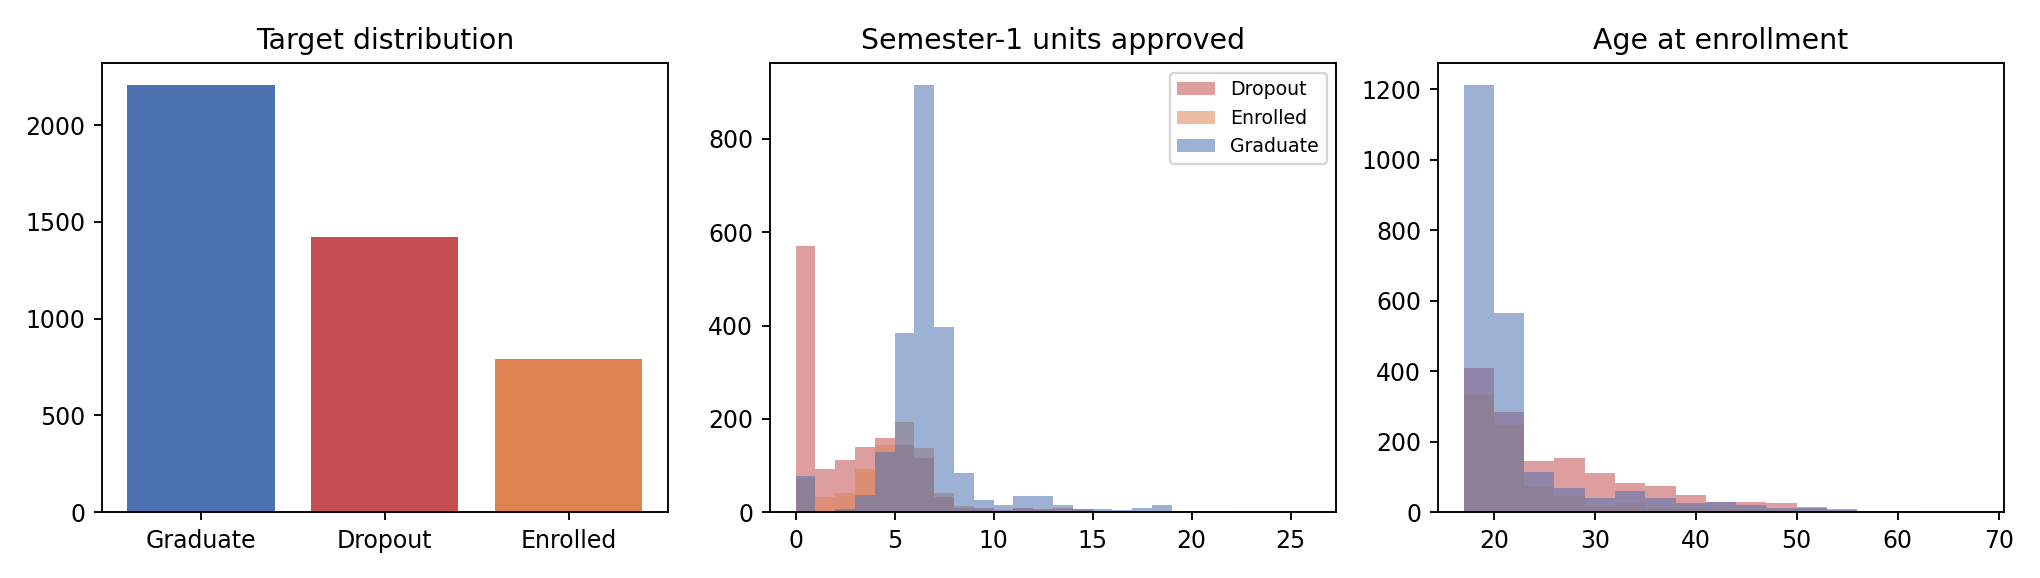

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
colors = {'Dropout':'#c44e52','Enrolled':'#dd8452','Graduate':'#4c72b0'}
vc = df[TARGET].value_counts(); ax[0].bar(vc.index, vc.values, color=[colors[k] for k in vc.index]); ax[0].set_title('Target distribution')
for t in colors:
    ax[1].hist(df[df[TARGET]==t]['Curricular units 1st sem (approved)'], bins=range(0,27), alpha=.55, label=t, color=colors[t])
    ax[2].hist(df[df[TARGET]==t]['Age at enrollment'], bins=range(17,70,3), alpha=.55, label=t, color=colors[t])
ax[1].set_title('Semester-1 units approved'); ax[2].set_title('Age at enrollment'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('../figures/eda_overview.png', dpi=170); plt.show()

In [6]:
for c in ['Gender','Scholarship holder','Debtor','Tuition fees up to date']:
    print(c, '\n', df.groupby(c)[TARGET].value_counts(normalize=True).unstack().round(3), '\n')

Gender 
 Target  Dropout  Enrolled  Graduate
Gender                             
0         0.251     0.170     0.579
1         0.451     0.197     0.352 

Scholarship holder 
 Target              Dropout  Enrolled  Graduate
Scholarship holder                             
0                     0.387     0.200     0.413
1                     0.122     0.118     0.760 

Debtor 
 Target  Dropout  Enrolled  Graduate
Debtor                             
0         0.283     0.180     0.538
1         0.620     0.179     0.201 

Tuition fees up to date 
 Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
0                          0.866     0.080     0.055
1                          0.247     0.193     0.560 



In [7]:
corr = df.drop(columns=TARGET).corrwith((df[TARGET]=='Dropout').astype(int)).sort_values(key=abs, ascending=False)
corr.head(10).round(3)

Curricular units 2nd sem (grade)      -0.572
Curricular units 2nd sem (approved)   -0.570
Curricular units 1st sem (grade)      -0.481
Curricular units 1st sem (approved)   -0.479
Tuition fees up to date               -0.429
Age at enrollment                      0.254
Scholarship holder                    -0.245
Debtor                                 0.229
Gender                                 0.204
Application mode                       0.198
dtype: float64

## 4. Data-quality checks and risks found

In [8]:
z1 = df[df['Curricular units 1st sem (enrolled)']==0][TARGET].value_counts()
z2 = df[df['Curricular units 2nd sem (enrolled)']==0][TARGET].value_counts()
print('Students with 0 units enrolled in sem 1:', int(z1.sum()), z1.to_dict())
print('Students with 0 units enrolled in sem 2:', int(z2.sum()), z2.to_dict())
print('Age >= 25 at enrollment (mature students):', round((df['Age at enrollment']>=25).mean(),3))
print('International:', round(df['International'].mean(),3), '| Educational special needs:', round(df['Educational special needs'].mean(),3))
print('Rare categories (<10 rows) per categorical column:')
for c in CATEGORICAL: print(f'  {c:28s} {df[c].nunique():3d} levels, {(df[c].value_counts()<10).sum():3d} rare')

Students with 0 units enrolled in sem 1: 180 {'Dropout': 77, 'Graduate': 75, 'Enrolled': 28}
Students with 0 units enrolled in sem 2: 180 {'Dropout': 77, 'Graduate': 75, 'Enrolled': 28}
Age >= 25 at enrollment (mature students): 0.257
International: 0.025 | Educational special needs: 0.012
Rare categories (<10 rows) per categorical column:
  Marital status                 6 levels,   2 rare
  Application mode              18 levels,   4 rare
  Course                        17 levels,   0 rare
  Previous qualification        17 levels,   7 rare
  Nacionality                   21 levels,  16 rare
  Mother's qualification        29 levels,  19 rare
  Father's qualification        34 levels,  22 rare
  Mother's occupation           32 levels,  18 rare
  Father's occupation           46 levels,  32 rare


**Risks recorded**
1. *Timing / leakage*: `Tuition fees up to date` and `Debtor` are strong predictors, but the dataset does not state when they were recorded; they may reflect status near the outcome. Semester-2 features are only available late. We therefore define two feature sets: **early** (enrollment + semester 1, 30 features) and **full** (adds semester 2, 36 features).
2. *Ambiguous class*: `Enrolled` students have not finished, so their label is not final.
3. *Sensitive attributes*: gender, nationality, marital status, special needs and parental occupation. We do not use the model to make individual decisions; subgroup performance is reported.
4. *Odd records*: 180 students have zero units enrolled in both semesters (and 75 of them are labelled Graduate), probably credit transfers. We keep them and run a sensitivity check without them.
5. *Single institution / country*: results may not generalise.

## 5. Train / validation / test strategy
Stratified 70/15/15 split, `random_state=42`, stored in `data/split_indices.json`. Hyperparameters are tuned with 5-fold stratified CV on the training set (validation set for model checks); the test set is used **once**, for final evaluation. Preprocessing (scaling, one-hot encoding) is fit inside a scikit-learn `Pipeline` on training folds only.

In [9]:
Xtr, Xva, Xte, ytr, yva, yte = make_splits(df)
summary = pd.DataFrame({'train': ytr.value_counts(), 'val': yva.value_counts(), 'test': yte.value_counts()})
summary.loc['total'] = summary.sum(); summary

          train  val  test
Target                    
Graduate   1546  332   331
Dropout     994  213   214
Enrolled    556  119   119
total      3096  664   664

## 6. Feasibility check (not final results)
One run per model, default settings, validation set, to confirm the task is learnable and that baselines are beaten. Primary metric: **macro-F1** (chosen before final experimentation).

In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score
fs = feature_sets(df)
def run(cols, model):
    cc = [c for c in CATEGORICAL if c in cols]; nn = [c for c in cols if c not in cc]
    pipe = Pipeline([('prep', ColumnTransformer([('c', OneHotEncoder(handle_unknown='ignore'), cc), ('n', StandardScaler(), nn)])), ('m', model)]).fit(Xtr[cols], ytr)
    p = pipe.predict(Xva[cols]); return round(f1_score(yva, p, average='macro'), 3), round(accuracy_score(yva, p), 3)
models = {'Majority class': DummyClassifier(strategy='most_frequent'), 'Stratified random': DummyClassifier(strategy='stratified', random_state=42),
          'Logistic regression': LogisticRegression(max_iter=3000), 'Decision tree (depth 5)': DecisionTreeClassifier(max_depth=5, random_state=42)}
rows = [(n, *run(fs['early'], m), *run(fs['full'], m)) for n, m in models.items()]
pd.DataFrame(rows, columns=['Model', 'early macro-F1', 'early acc', 'full macro-F1', 'full acc'])

                     Model  early macro-F1  early acc  full macro-F1  full acc
0           Majority class           0.222      0.500          0.222     0.500
1        Stratified random           0.313      0.373          0.313     0.373
2      Logistic regression           0.651      0.736          0.705     0.773
3  Decision tree (depth 5)           0.549      0.703          0.602     0.720